In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import ast

# ─── Load ─────────────────────────────────────────────────────────────────────

df = pd.read_csv("C:\\Szonja\\UNI\\FYP\\MantiShrimp-main - Copy\\script\\12052026_exhaustion.csv.gz", compression="gzip")
df["alive_status"] = df["alive_status"].map(
    {True: True, False: False, "True": True, "False": False, 1: True, 0: False}
)



In [ ]:
image_step = 1   # choose the step/frame you want to show

TRAJ_STEPS = 0      # number of steps to show as trailing track
traj_start = max(0, image_step - TRAJ_STEPS)
traj_df   = df[df["step"] >= traj_start].copy()
plot_traj_df = traj_df[traj_df["step"] <= image_step].copy()
final_df = traj_df[traj_df["step"] == image_step].copy()

BOX = 600            # domain half-width


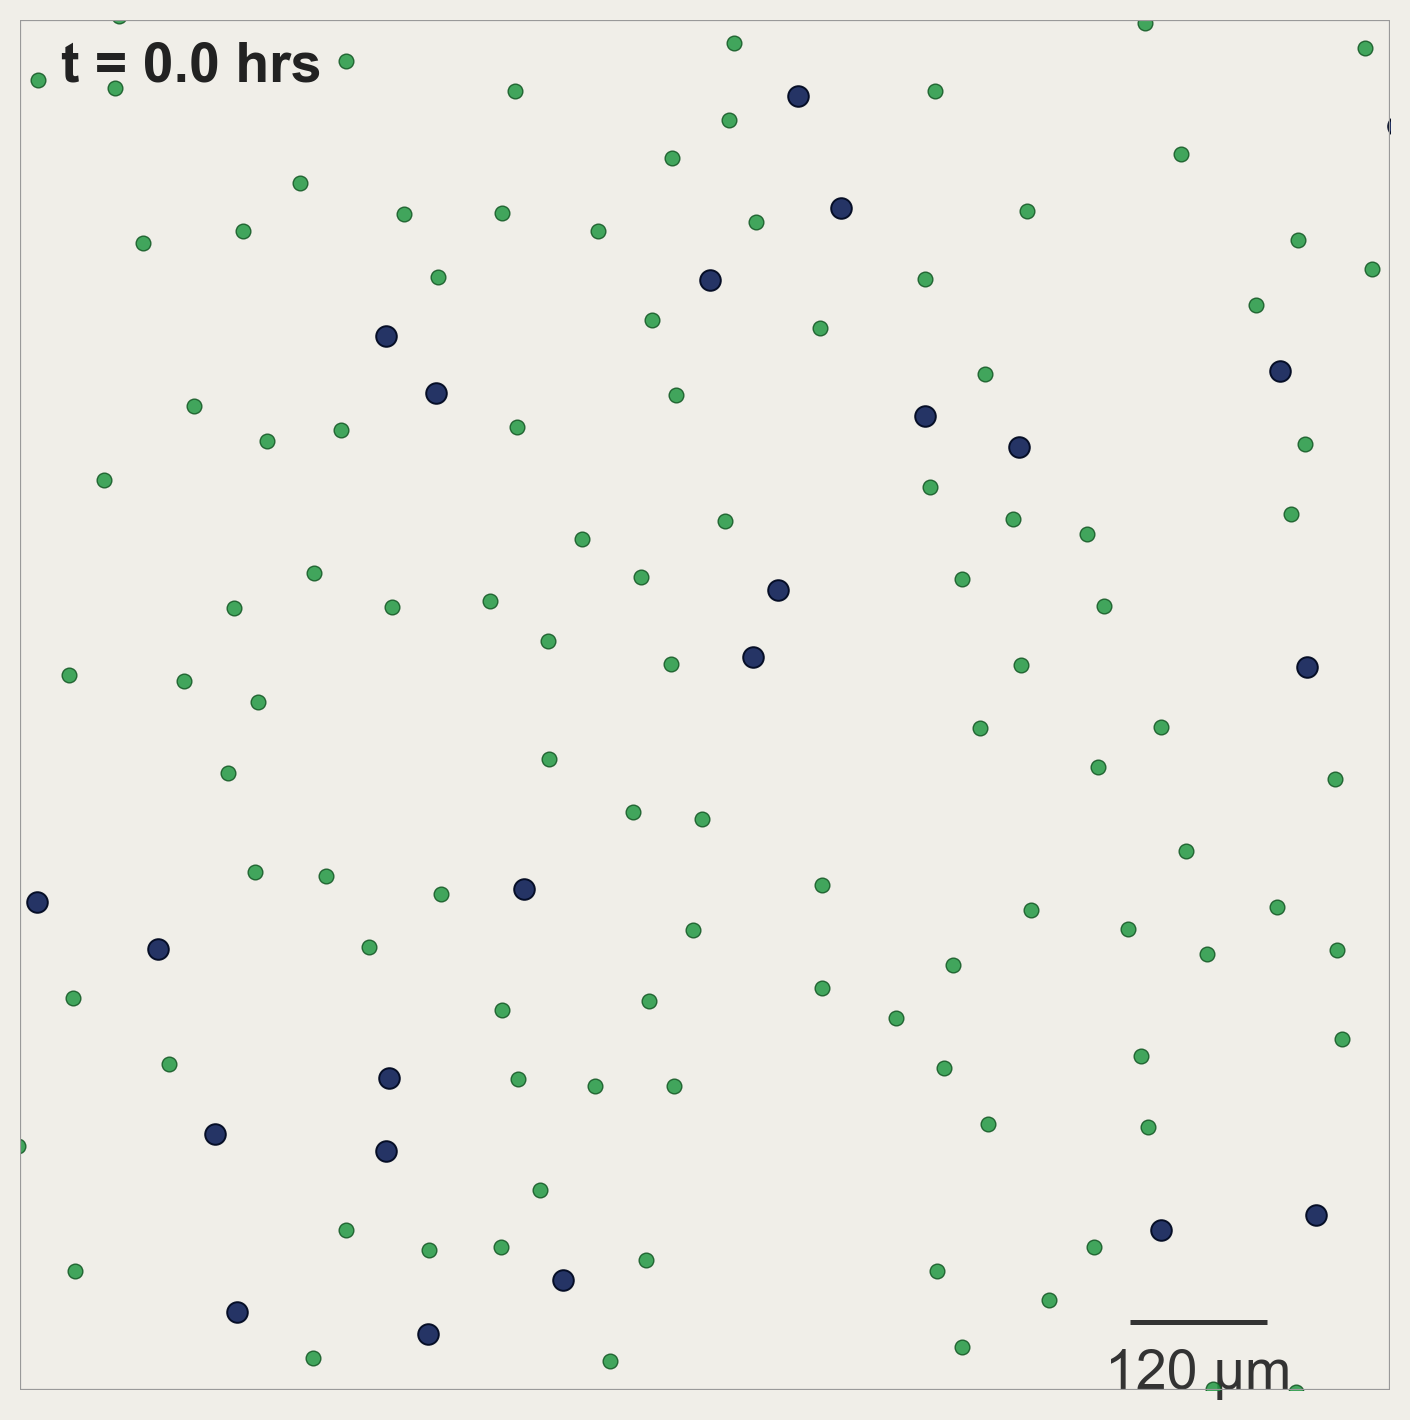

Saved: ABM_snapshot_imaging.png


In [ ]:


def unwrap_trajectory_anchored_to_final(g, box_half_width):
    """
    Reconstruct a continuous trajectory under periodic boundary conditions,
    anchored so the final point is exactly the recorded final x,y position.

    This prevents fake long jumps and makes the track connect to the final cell dot.
    """
    g = g.sort_values("step")
    pts = g[["x", "y"]].to_numpy(float)

    if len(pts) < 2:
        return pts

    period = 2 * box_half_width
    unwrapped = np.zeros_like(pts)

    # Anchor final point exactly where the final cell is plotted
    unwrapped[-1] = pts[-1]

    # Walk backwards from final position
    for i in range(len(pts) - 2, -1, -1):
        delta = pts[i] - pts[i + 1]

        # Minimum-image correction for periodic boundary jumps
        delta = (delta + box_half_width) % period - box_half_width

        unwrapped[i] = unwrapped[i + 1] + delta

    return unwrapped


killer_tracks_all = []
target_tracks_all = []

for (cell_type, cell_id), g in plot_traj_df.groupby(["cell_type", "cell_id"]):
    xy = unwrap_trajectory_anchored_to_final(g, BOX)

    if cell_type == "killer":
        killer_tracks_all.append(xy)
    else:
        target_tracks_all.append(xy)


fig, ax = plt.subplots(figsize=(7, 7), dpi=200)
fig.patch.set_facecolor("#F0EEE8") 
ax.set_facecolor("#F0EEE8")

ax.set_xlim(-BOX, BOX)
ax.set_ylim(-BOX, BOX)
ax.set_aspect("equal")
ax.axis("off")

#  Draw killer tracks with fading and thickening towards the end
for track in killer_tracks_all:
    if len(track) < 2:
        continue

    n = len(track)

    for i in range(1, n):
        alpha = 0.15 + 0.70 * (i / n)
        lw = 0.6 + 1.0 * (i / n)

        ax.plot(
            track[i-1:i+1, 0],
            track[i-1:i+1, 1],
            color="#1a2a5e",
            alpha=alpha,
            linewidth=lw,
            solid_capstyle="round",
            zorder=2,
        )


# Draw target tracks with fading but thin lines
for track in target_tracks_all:
    if len(track) < 2:
        continue

    n = len(track)

    for i in range(1, n):
        alpha = 0.05 + 0.25 * (i / n)

        ax.plot(
            track[i-1:i+1, 0],
            track[i-1:i+1, 1],
            color="#888888",
            alpha=alpha,
            linewidth=0.4,
            solid_capstyle="round",
            zorder=1,
        )

#    Draw final-frame cells     

targets_final = final_df[final_df["cell_type"] == "target"]
killers_final = final_df[final_df["cell_type"] == "killer"]

# Dead targets
dead = targets_final[targets_final["alive_status"] == False]
ax.scatter(
    dead["x"], dead["y"],
    s=28, color="#CC2222", edgecolors="#880000",
    linewidths=0.5, zorder=5, alpha=0.90,
)

# Alive targets
alive = targets_final[targets_final["alive_status"] == True]
ax.scatter(
    alive["x"], alive["y"],
    s=28, color="#229944", edgecolors="#115522",
    linewidths=0.5, zorder=5, alpha=0.85,
)

# Killers
ax.scatter(
    killers_final["x"], killers_final["y"],
    s=55, color="#1a2a5e", edgecolors="#000820",
    linewidths=0.7, zorder=6, alpha=0.95,
    marker="o",
)

#    Thin boundary box  
for spine_x in [(-BOX, BOX), (-BOX, BOX)]:
    pass
rect = mpatches.FancyBboxPatch(
    (-BOX, -BOX), 2*BOX, 2*BOX,
    boxstyle="square,pad=0",
    linewidth=0.8, edgecolor="#999999",
    facecolor="none", zorder=10,
)
ax.add_patch(rect)

# Scale bar (100 μm equivalent — adjust if you know your DS)
scale_x0, scale_y0 = BOX * 0.62, -BOX * 0.90
scale_len = 120    # in simulation units
ax.plot(
    [scale_x0, scale_x0 + scale_len],
    [scale_y0, scale_y0],
    color="#333333", linewidth=1.8, solid_capstyle="butt", zorder=11,
)
ax.text(
    scale_x0 + scale_len / 2, scale_y0 - BOX * 0.04,
    "120 μm", ha="center", va="top",
    fontsize=20, color="#333333", fontfamily="Arial",
)

# Time label
t_final = final_df["time"].iloc[0]
ax.text(
    -BOX * 0.94, BOX * 0.91,
    f"t = {t_final:.1f} hrs",
    fontsize=20, color="#222222", fontfamily="Arial",
    fontweight="bold", zorder=11,
)

# Legend
legend_elements = [
    Line2D([0],[0], color="#1a2a5e", linewidth=1.5,
           label="NK cell track"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#1a2a5e",
           markersize=14, markeredgecolor="#000820", markeredgewidth=0.5,
           label="NK cell (final position)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#229944",
           markersize=14, markeredgecolor="#115522", markeredgewidth=0.5,
           label="Target (alive)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#CC2222",
           markersize=14, markeredgecolor="#880000", markeredgewidth=0.5,
           label="Target (dead)"),
]
#leg = ax.legend(
 #   handles=legend_elements,
  #  loc="lower left", bbox_to_anchor=(0.01, 0.01),
   # frameon=True, framealpha=0.75,
    #edgecolor="#CCCCCC", facecolor="#F8F6F2",
    #fontsize=14,
#)

#for t in leg.get_texts():
 #   t.set_fontfamily("Arial")

plt.tight_layout(pad=0.2)
plt.savefig("ABM_snapshot_imaging.png", dpi=300, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: ABM_snapshot_imaging.png")